In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('AAPL.csv')
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [16]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [48]:
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [17]:
# Convert 'Date' to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [20]:
# Select the 'Close' price for analysis
ts = df['Close']
ts.head()

Date
1980-12-12    0.513393
1980-12-15    0.486607
1980-12-16    0.450893
1980-12-17    0.462054
1980-12-18    0.475446
Name: Close, dtype: float64

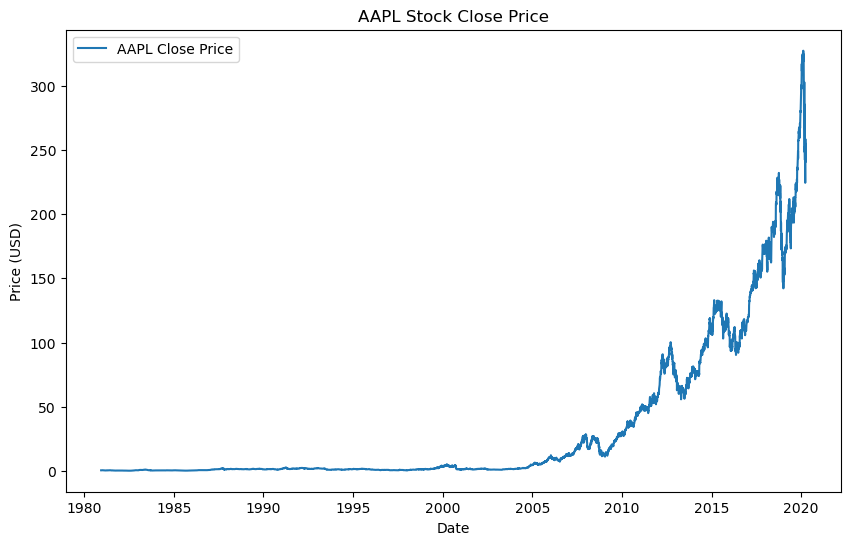

In [21]:
# Plot the time series
plt.figure(figsize=(10, 6))
plt.plot(ts, label='AAPL Close Price')
plt.title('AAPL Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### Step 2: Decompose the Time Series


In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series (additive model)
decomposition = seasonal_decompose(ts, model='additive', period=252)  # Assuming ~252 trading days in a year

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


In [69]:
trend.isnull().sum(), seasonal.isnull().sum(), residual.isnull().sum()


(252, 0, 252)

In [70]:
trend

Date
1980-12-12   NaN
1980-12-15   NaN
1980-12-16   NaN
1980-12-17   NaN
1980-12-18   NaN
              ..
2020-03-26   NaN
2020-03-27   NaN
2020-03-30   NaN
2020-03-31   NaN
2020-04-01   NaN
Name: trend, Length: 9909, dtype: float64

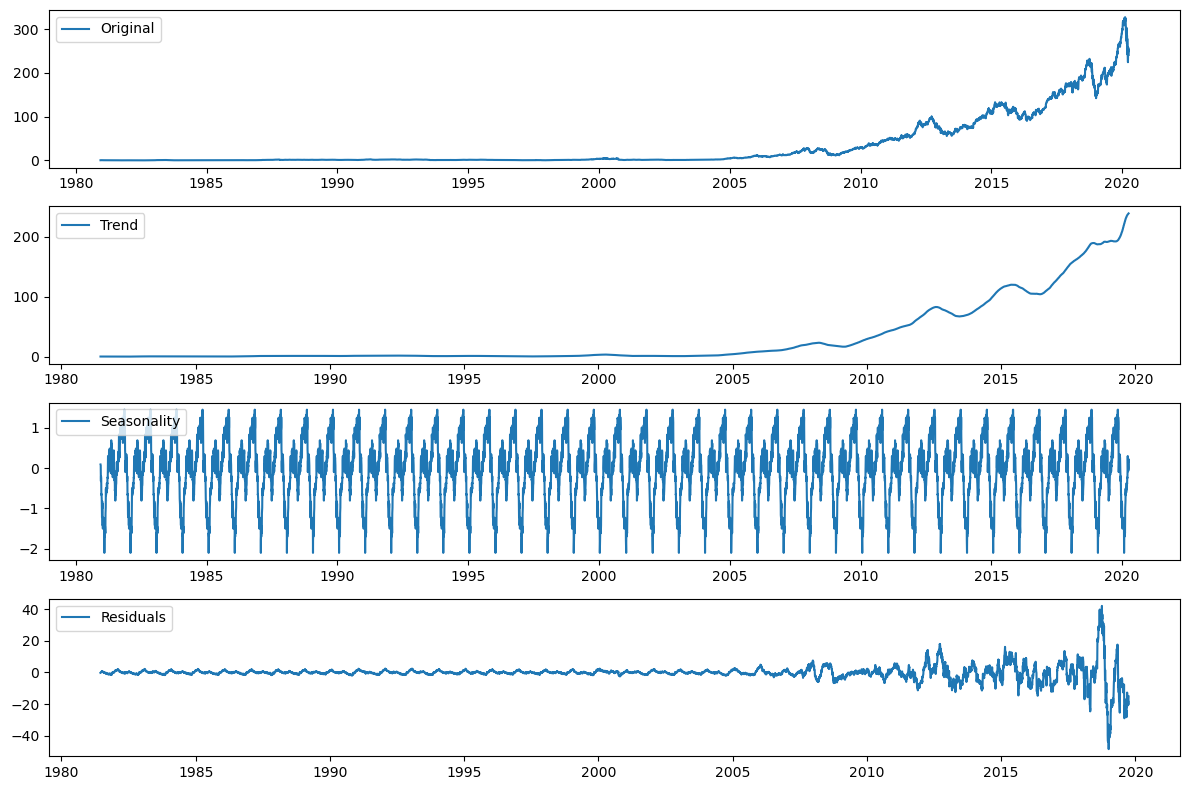

In [27]:
# Plot the decomposition
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(ts, label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Step 3: Implement Moving Average and Exponential Smoothing



In [59]:
# Simple Moving Average (window of 30 days)
ma_window = 200
ma = ts.rolling(window=ma_window).mean()

In [65]:
# Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
es_model = ExponentialSmoothing(ts, trend='add', seasonal=None).fit()
es_forecast = es_model.fittedvalues

/home/musty/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


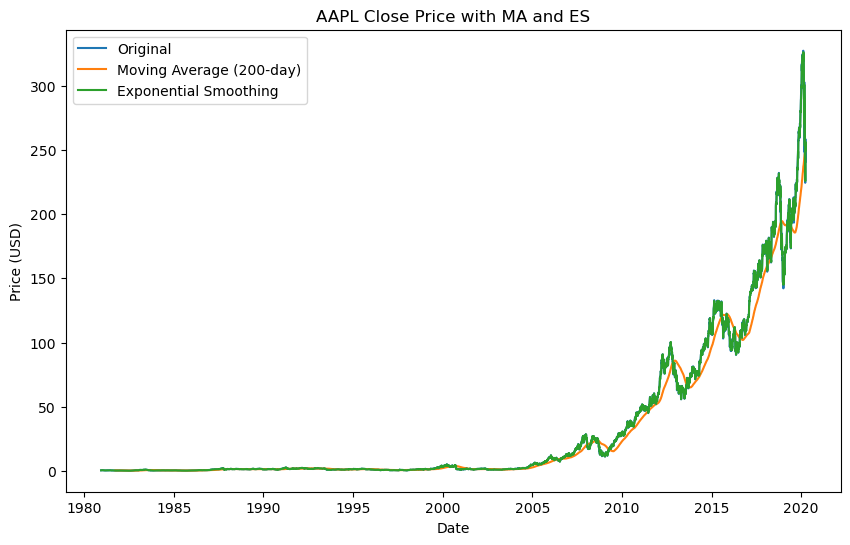

In [66]:
# Plot MA and ES
plt.figure(figsize=(10, 6))
plt.plot(ts, label='Original')
plt.plot(ma, label=f'Moving Average ({ma_window}-day)')
plt.plot(es_forecast, label='Exponential Smoothing')
plt.title('AAPL Close Price with MA and ES')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### Step 4: Build an ARIMA or SARIMA Model

In [31]:
from statsmodels.tsa.stattools import adfuller

# ADF test for stationarity
result = adfuller(ts)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 1.8939738468260825
p-value: 0.9985182618845982


In [32]:
# If non-stationary (p-value > 0.05), difference the series
ts_diff = ts.diff().dropna()
result_diff = adfuller(ts_diff)
print('ADF Statistic (Differenced):', result_diff[0])
print('p-value (Differenced):', result_diff[1])

ADF Statistic (Differenced): -15.355344806468114
p-value (Differenced): 3.6731446695781244e-28


In [35]:
from pmdarima import auto_arima

# Fit auto_arima to find optimal parameters
arima_model = auto_arima(ts, start_p=0, start_q=0, max_p=3, max_q=3, d=1, seasonal=False, trace=True, error_action='ignore',suppress_warnings=True, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=33875.331, Time=0.37 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=33564.566, Time=0.85 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=33576.468, Time=1.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=33876.594, Time=0.27 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=33566.543, Time=1.16 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=33566.547, Time=1.63 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=33532.289, Time=12.41 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=33349.075, Time=11.86 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=33565.261, Time=2.38 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=33344.767, Time=13.17 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=33568.405, Time=3.84 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=25.40 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=33396.757, Time=17.35 sec
 ARIMA(3,1,2)(0,0,0)[0]             : AIC=33344.970, Time=5.65 sec

Best model:  ARIMA(

In [36]:
# Print model summary
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 9909
Model:               SARIMAX(3, 1, 2)   Log Likelihood              -16665.384
Date:                Fri, 20 Jun 2025   AIC                          33344.767
Time:                        14:25:10   BIC                          33395.175
Sample:                             0   HQIC                         33361.838
                               - 9909                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0029      0.002      1.190      0.234      -0.002       0.008
ar.L1         -0.1591      0.006    -28.410      0.000      -0.170      -0.148
ar.L2          0.8106      0.006    125.204      0.0

In [37]:
# Fit the ARIMA model
arima_fitted = arima_model.fit(ts)

In [38]:
# Forecast the next 30 days
forecast_steps = 30
forecast = arima_fitted.predict(n_periods=forecast_steps)

/home/musty/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/musty/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [81]:
forecast.shape

(30,)

### Step 5: Evaluate the Model and Visualize the Forecast

In [43]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Split data into train (80%) and test (20%)
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

In [44]:
# Fit ARIMA on training data
arima_model = auto_arima(train, start_p=0, start_q=0, max_p=3, max_q=3, d=1, 
                         seasonal=False, trace=True, error_action='ignore', 
                         suppress_warnings=True, stepwise=True)
arima_fitted = arima_model.fit(train)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3776.280, Time=1.84 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3776.843, Time=2.42 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3776.852, Time=1.76 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3782.528, Time=0.71 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3756.563, Time=5.81 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3745.193, Time=8.88 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=3778.803, Time=1.23 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=3737.056, Time=8.11 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=3766.945, Time=1.56 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=3739.057, Time=14.69 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3740.616, Time=9.81 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=3743.399, Time=3.16 sec

Best model:  ARIMA(3,1,1)(0,0,0)[0] intercept
Total fit time: 59.982 seconds


In [45]:
# Predict on test set
test_forecast = arima_fitted.predict(n_periods=len(test))


/home/musty/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/musty/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [46]:
# Calculate RMSE
rmse = sqrt(mean_squared_error(test, test_forecast))
print(f'RMSE: {rmse}')

RMSE: 69.74333565148028


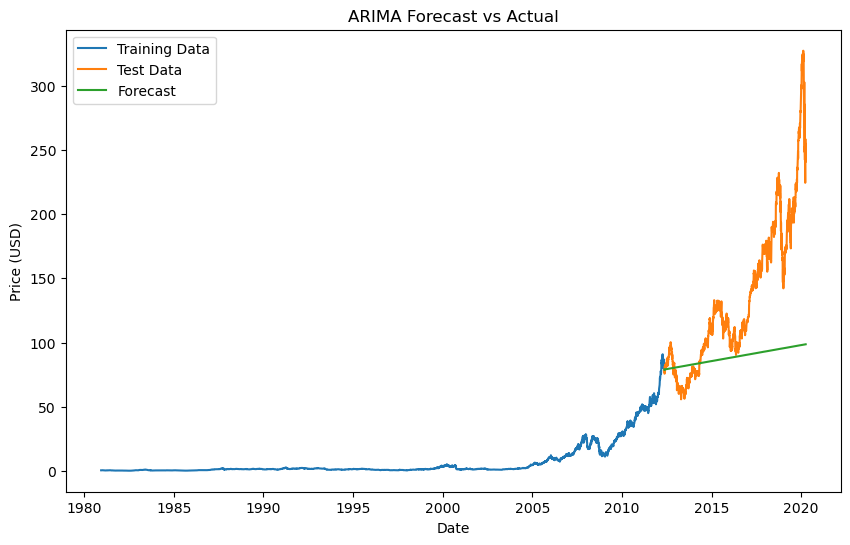

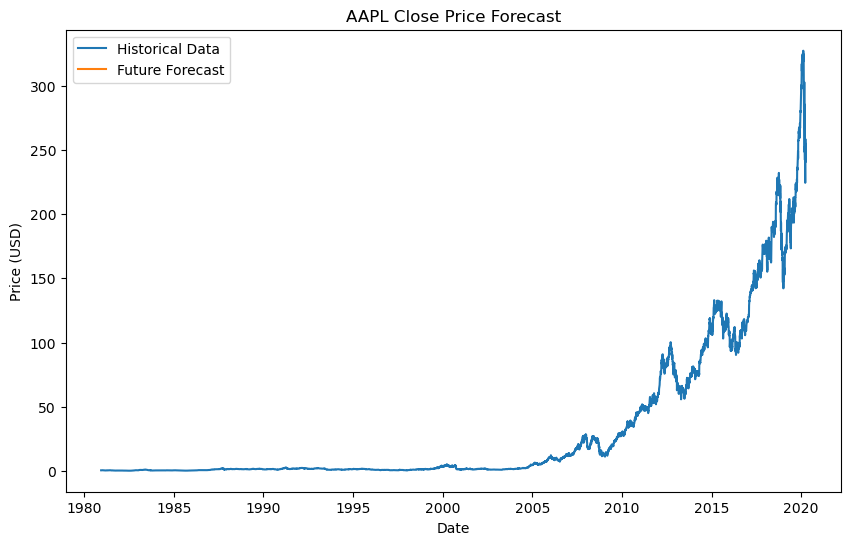

In [47]:
# Plot actual vs forecast
plt.figure(figsize=(10, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Test Data')
plt.plot(test.index, test_forecast, label='Forecast')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Plot future forecast
plt.figure(figsize=(10, 6))
plt.plot(ts, label='Historical Data')
plt.plot(forecast_series, label='Future Forecast')
plt.title('AAPL Close Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()